In [19]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler 


In [20]:
data=pd.read_csv(r"C:\Users\GIBSON\Desktop\Air_Pollution\pollution_dataset.csv")
data

,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density,Air Quality
0,29.8,59.1,5.2,17.9,18.9,9.2,1.72,6.3,319,Moderate
1,28.3,75.6,2.3,12.2,30.8,9.7,1.64,6.0,611,Moderate
2,23.1,74.7,26.7,33.8,24.4,12.6,1.63,5.2,619,Moderate
3,27.1,39.1,6.1,6.3,13.5,5.3,1.15,11.1,551,Good
4,26.5,70.7,6.9,16.0,21.9,5.6,1.01,12.7,303,Good
...,...,...,...,...,...,...,...,...,...,...
4995,40.6,74.1,116.0,126.7,45.5,25.7,2.11,2.8,765,Hazardous
4996,28.1,96.9,6.9,25.0,25.3,10.8,1.54,5.7,709,Moderate
4997,25.9,78.2,14.2,22.1,34.8,7.8,1.63,9.6,379,Moderate
4998,25.3,44.4,21.4,29.0,23.7,5.7,0.89,11.6,241,Good


In [21]:
data.isnull().sum()

Temperature                      0
Humidity                         0
PM2.5                            0
PM10                             0
NO2                              0
SO2                              0
CO                               0
Proximity_to_Industrial_Areas    0
Population_Density               0
Air Quality                      0
dtype: int64

In [22]:
data.shape

(5000, 10)

In [23]:
data.dtypes

Temperature                      float64
Humidity                         float64
PM2.5                            float64
PM10                             float64
NO2                              float64
SO2                              float64
CO                               float64
Proximity_to_Industrial_Areas    float64
Population_Density                 int64
Air Quality                       object
dtype: object

In [24]:
data["Air Quality"].value_counts()

Air Quality
Good         2000
Moderate     1500
Poor         1000
Hazardous     500
Name: count, dtype: int64

<Axes: ylabel='count'>

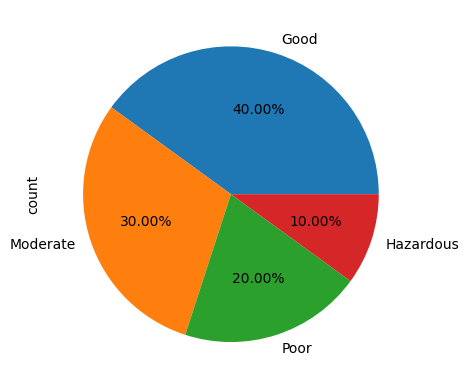

In [25]:
data["Air Quality"].value_counts().plot.pie(autopct='%.2f%%')

In [26]:
data.columns

Index(['Temperature', 'Humidity', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO',
       'Proximity_to_Industrial_Areas', 'Population_Density', 'Air Quality'],
      dtype='object')

In [27]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Temperature                    5000 non-null   float64
 1   Humidity                       5000 non-null   float64
 2   PM2.5                          5000 non-null   float64
 3   PM10                           5000 non-null   float64
 4   NO2                            5000 non-null   float64
 5   SO2                            5000 non-null   float64
 6   CO                             5000 non-null   float64
 7   Proximity_to_Industrial_Areas  5000 non-null   float64
 8   Population_Density             5000 non-null   int64  
 9   Air Quality                    5000 non-null   object 
dtypes: float64(8), int64(1), object(1)
memory usage: 390.8+ KB


In [28]:
c=LabelEncoder()
data["Air Quality"]=c.fit_transform(data["Air Quality"])

In [29]:
data["Air Quality"].value_counts()

Air Quality
0    2000
2    1500
3    1000
1     500
Name: count, dtype: int64

In [30]:
data.head()

,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density,Air Quality
0,29.8,59.1,5.2,17.9,18.9,9.2,1.72,6.3,319,2
1,28.3,75.6,2.3,12.2,30.8,9.7,1.64,6.0,611,2
2,23.1,74.7,26.7,33.8,24.4,12.6,1.63,5.2,619,2
3,27.1,39.1,6.1,6.3,13.5,5.3,1.15,11.1,551,0
4,26.5,70.7,6.9,16.0,21.9,5.6,1.01,12.7,303,0


In [31]:
x=data.drop(["Air Quality"], axis=1)
y=data["Air Quality"]

In [32]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2, random_state=42)

In [33]:
from imblearn.over_sampling import SMOTE
from collections import Counter

print("Before SMOTE:", Counter(y_train))

smote = SMOTE(random_state=42)
x_train, y_train = smote.fit_resample(x_train, y_train)

print("After SMOTE:", Counter(y_train))

Before SMOTE: Counter({0: 1591, 2: 1206, 3: 814, 1: 389})
After SMOTE: Counter({1: 1591, 0: 1591, 3: 1591, 2: 1591})


In [ ]:
print(x_train.shape)
print(x_test.shape)
print(y_test.shape)
print(y_train.shape)

(6364, 9)
(1000, 9)
(1000,)
(6364,)


In [ ]:
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [ ]:
#0-LogisticRegression

from sklearn.linear_model import LogisticRegression 
model0=LogisticRegression(max_iter=5000)
model0.fit(x_train_scaled,y_train)
pred0=model0.predict(x_test_scaled)

accuracy_score(y_test,pred0)


0.938

In [ ]:
cr=classification_report(y_test,pred0)
print("classification_report", cr)
cm=confusion_matrix(y_test,pred0)
print("confusion_matrix ", cm)

classification_report               precision    recall  f1-score   support

           0       1.00      1.00      1.00       409
           1       0.84      0.87      0.86       111
           2       0.96      0.94      0.95       294
           3       0.83      0.84      0.83       186

    accuracy                           0.94      1000
   macro avg       0.91      0.91      0.91      1000
weighted avg       0.94      0.94      0.94      1000

confusion_matrix  [[409   0   0   0]
 [  0  97   0  14]
 [  0   0 276  18]
 [  0  18  12 156]]


In [ ]:
#1-DecisionTreeClassifier

from sklearn.tree import DecisionTreeClassifier
model1=DecisionTreeClassifier(criterion="entropy")
model1=model1.fit(x_train,y_train)
pred1=model1.predict(x_test)

accuracy_score(y_test,pred1)

0.925

In [ ]:
cr=classification_report(y_test,pred1)
print("classification_report", cr)
cm=confusion_matrix(y_test,pred1)
print("confusion_matrix ", cm)

classification_report               precision    recall  f1-score   support

           0       0.99      1.00      1.00       409
           1       0.79      0.83      0.81       111
           2       0.96      0.94      0.95       294
           3       0.81      0.81      0.81       186

    accuracy                           0.93      1000
   macro avg       0.89      0.89      0.89      1000
weighted avg       0.93      0.93      0.93      1000

confusion_matrix  [[408   0   1   0]
 [  0  92   0  19]
 [  3   0 275  16]
 [  0  25  11 150]]


In [ ]:
#2-SVM

from sklearn import svm
model2=svm.SVC(kernel="linear")
model2.fit(x_train_scaled,y_train)
pred2=model2.predict(x_test_scaled)

accuracy_score(y_test,pred2)


0.94

In [ ]:
cr=classification_report(y_test,pred2)
print("classification_report", cr)
cm=confusion_matrix(y_test,pred2)
print("confusion_matrix ", cm)

classification_report               precision    recall  f1-score   support

           0       1.00      1.00      1.00       409
           1       0.83      0.88      0.86       111
           2       0.96      0.95      0.95       294
           3       0.85      0.83      0.84       186

    accuracy                           0.94      1000
   macro avg       0.91      0.91      0.91      1000
weighted avg       0.94      0.94      0.94      1000

confusion_matrix  [[409   0   0   0]
 [  0  98   0  13]
 [  0   0 279  15]
 [  0  20  12 154]]


In [36]:
#3-RandomForest

from sklearn.ensemble import RandomForestClassifier
model3=RandomForestClassifier(criterion="gini",random_state=48)
model3.fit(x_train,y_train)
pred3=model3.predict(x_test)

accuracy_score(y_test,pred3)



0.952

In [ ]:
cr=classification_report(y_test,pred3)
print("classification_report", cr)
cm=confusion_matrix(y_test,pred3)
print("confusion_matrix ", cm)

classification_report               precision    recall  f1-score   support

           0       1.00      1.00      1.00       409
           1       0.86      0.93      0.89       111
           2       0.97      0.96      0.96       294
           3       0.88      0.85      0.87       186

    accuracy                           0.95      1000
   macro avg       0.93      0.93      0.93      1000
weighted avg       0.95      0.95      0.95      1000

confusion_matrix  [[409   0   0   0]
 [  0 103   0   8]
 [  0   0 281  13]
 [  0  17  10 159]]



Feature Importance:
                         Feature  Importance
6                             CO    0.372744
7  Proximity_to_Industrial_Areas    0.196276
4                            NO2    0.144637
0                    Temperature    0.085012
5                            SO2    0.077836
8             Population_Density    0.046801
1                       Humidity    0.037190
3                           PM10    0.023539
2                          PM2.5    0.015966


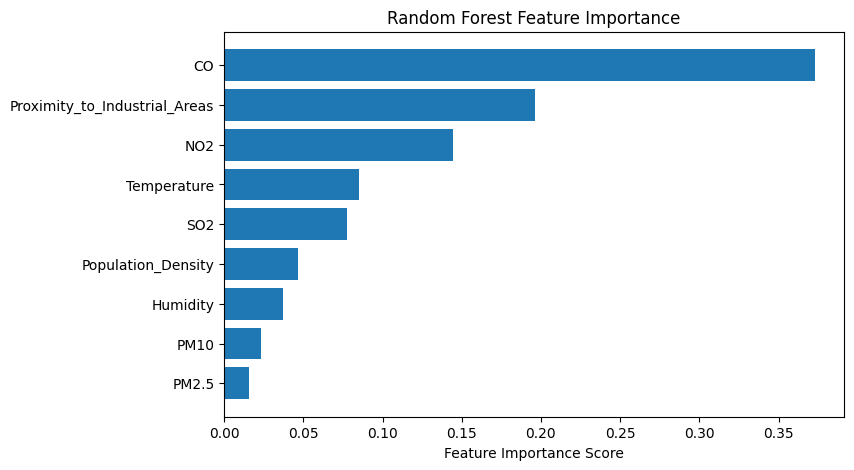

In [ ]:
# Feature importance part 
importances = model3.feature_importances_
feature_names = x_train.columns   # works if x_train is a DataFrame

# Create DataFrame for better readability
feat_importances = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance:")
print(feat_importances)

# Plot
plt.figure(figsize=(8,5))
plt.barh(feat_importances["Feature"], feat_importances["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance Score")
plt.title("Random Forest Feature Importance")
plt.show()

In [ ]:
#4-naive_bayes

from sklearn.naive_bayes import GaussianNB
model4=GaussianNB()
model4.fit(x_train,y_train)
pred4=model4.predict(x_test)

accuracy_score(y_test,pred4)

0.925

In [ ]:
cr=classification_report(y_test,pred4)
print("classification_report", cr)
cm=confusion_matrix(y_test,pred4)
print("confusion_matrix ", cm)

classification_report               precision    recall  f1-score   support

           0       1.00      0.99      0.99       409
           1       0.84      0.84      0.84       111
           2       0.94      0.92      0.93       294
           3       0.80      0.84      0.82       186

    accuracy                           0.93      1000
   macro avg       0.89      0.90      0.90      1000
weighted avg       0.93      0.93      0.93      1000

confusion_matrix  [[405   0   4   0]
 [  0  93   0  18]
 [  2   1 271  20]
 [  0  17  13 156]]


In [ ]:
#5-XGBoost

import xgboost as xgb
model5=xgb.XGBClassifier(n_estimators=100, learning_rate=0.1)
model5.fit(x_train,y_train)
pred5=model5.predict(x_test)

accuracy_score(y_test,pred5)

0.952

In [ ]:
cr=classification_report(y_test,pred5)
print("classification_report", cr)
cm=confusion_matrix(y_test,pred5)
print("confusion_matrix ", cm)

classification_report               precision    recall  f1-score   support

           0       1.00      1.00      1.00       409
           1       0.87      0.93      0.90       111
           2       0.98      0.94      0.96       294
           3       0.86      0.88      0.87       186

    accuracy                           0.95      1000
   macro avg       0.93      0.94      0.93      1000
weighted avg       0.95      0.95      0.95      1000

confusion_matrix  [[409   0   0   0]
 [  0 103   0   8]
 [  0   0 276  18]
 [  0  15   7 164]]


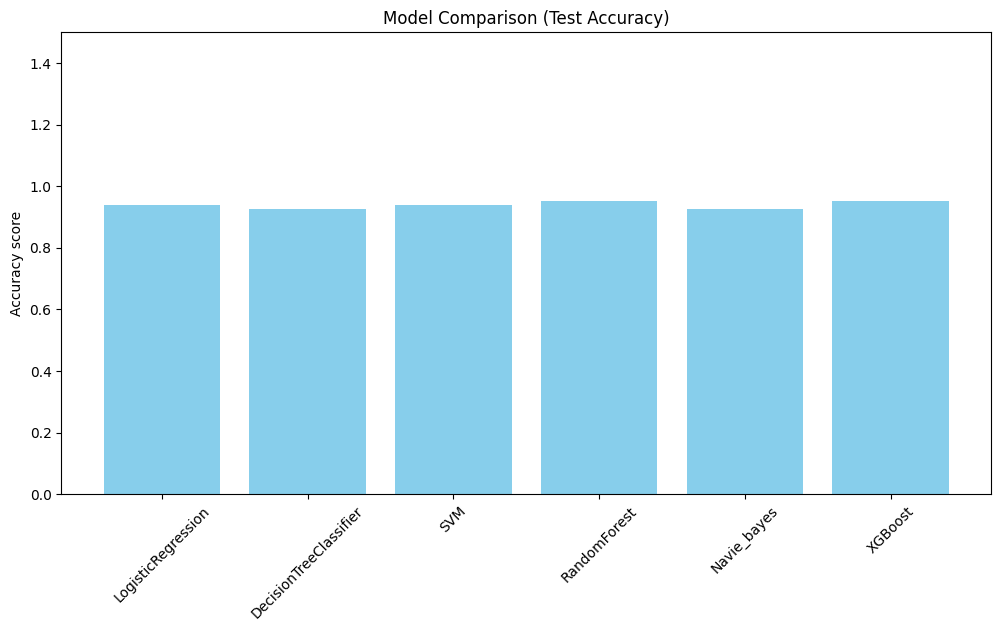

In [ ]:
import matplotlib.pyplot as plt

models=["LogisticRegression","DecisionTreeClassifier","SVM","RandomForest","Navie_bayes","XGBoost"]

accuracy_score=[.938,.925,.94,.952,.925,.952,]

plt.figure(figsize=(12,6))
plt.bar(models, accuracy_score, color='skyblue')
plt.ylabel('Accuracy score')
plt.title('Model Comparison (Test Accuracy)')
plt.xticks(rotation=45)
plt.ylim(0,1.5)          #"y-axis limits" → it tells the chart how high and low the vertical axis should go.
plt.show()


In [ ]:
import pickle

best_model=model3

with open("best_model.pkl","wb") as f:      #'wb'-write binary/ 'f'-is a variable
    pickle.dump(best_model,f)
    
print("best model saved")

best model saved


In [ ]:

# Saving the LabelEncoder

with open("encoder.pkl", "wb") as f:
    pickle.dump(c, f)
